# MuJoCo Warp Renderer Parity & Benchmarks

This notebook validates the Phase 1 renderer parity work and benchmarks the
mjwarp ray-traced renderer against `mujoco.Renderer` (OpenGL).

Each section exercises one of the lighting / material features wired up in
the Phase 1 PR:

1. **Headlight** — `vis.headlight` injection at the active camera\n
2. **Spotlight cutoff & exponent** — `light_cutoff`, `light_exponent`\n
3. **Distance attenuation** — `light_attenuation` 3-coefficient model\n
4. **Per-light color** — independent diffuse / specular per light\n
5. **Specular highlights** — Phong `mat_specular` / `mat_shininess`\n
6. **Material emission** — `mat_emission` self-illumination\n
7. **Shadows** — binary shadow rays

The final section times both renderers across resolutions and world counts.

> Run on a CUDA-enabled Warp build for meaningful multi-world benchmarks.
> On CPU the timings are still informative but rendering thousands of
> environments at once is not the design point.

## Setup

In [1]:
import time

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import warp as wp

import mujoco_warp as mjw

wp.init()
print("Warp devices:", [str(d) for d in wp.get_devices()])
print("CUDA devices:", wp.get_cuda_device_count())

Warp 1.13.0.dev20260227 initialized:
   Git commit: 0e622012c4291df7ad57cd8b6038d3498c6b5f60
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/mhasek/Library/Caches/warp/1.13.0.dev20260227
Warp devices: ['cpu']
CUDA devices: 0


In [2]:
def _unpack_rgb(packed: np.ndarray) -> np.ndarray:
  r = ((packed >> 16) & 0xFF).astype(np.uint8)
  g = ((packed >> 8) & 0xFF).astype(np.uint8)
  b = (packed & 0xFF).astype(np.uint8)
  return np.stack([r, g, b], axis=-1)


def mjwarp_render(
  mjm: mujoco.MjModel, w: int, h: int, use_shadows: bool = False, samples_per_pixel: int = 4
) -> np.ndarray:
  """Render `mjm` with mjwarp at WxH. Returns an HxWx3 uint8 RGB image.

  Defaults to 4x MSAA so silhouettes are anti-aliased. Pass
  `samples_per_pixel=1` to see the raw single-sample output.
  """
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd)
  rc = mjw.create_render_context(
    mjm, cam_res=(w, h), render_rgb=True, use_shadows=use_shadows, samples_per_pixel=samples_per_pixel
  )
  mjw.render(m, d, rc)
  return _unpack_rgb(rc.rgb_data.numpy()[0]).reshape(h, w, 3)


def mujoco_render(mjm: mujoco.MjModel, w: int, h: int) -> np.ndarray:
  """Render `mjm` with mujoco.Renderer at WxH. Returns an HxWx3 uint8 RGB image."""
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  with mujoco.Renderer(mjm, height=h, width=w) as r:
    r.update_scene(mjd, camera=0)
    return r.render()


def mean_l1(a: np.ndarray, b: np.ndarray) -> float:
  return float(np.abs(a.astype(np.float32) - b.astype(np.float32)).mean() / 255.0)


def ssim_luma(a: np.ndarray, b: np.ndarray, win: int = 8) -> float:
  """Compact box-window SSIM on luma. Same implementation as the parity tests."""
  ay = (0.299 * a[..., 0] + 0.587 * a[..., 1] + 0.114 * a[..., 2]).astype(np.float32) / 255.0
  by = (0.299 * b[..., 0] + 0.587 * b[..., 1] + 0.114 * b[..., 2]).astype(np.float32) / 255.0
  c1, c2 = (0.01) ** 2, (0.03) ** 2
  h, w = ay.shape
  hh, ww = h - h % win, w - w % win
  ay = ay[:hh, :ww].reshape(hh // win, win, ww // win, win)
  by = by[:hh, :ww].reshape(hh // win, win, ww // win, win)
  ay = ay.transpose(0, 2, 1, 3).reshape(-1, win * win)
  by = by.transpose(0, 2, 1, 3).reshape(-1, win * win)
  mu_a, mu_b = ay.mean(axis=1), by.mean(axis=1)
  va, vb = ay.var(axis=1), by.var(axis=1)
  cov = ((ay - mu_a[:, None]) * (by - mu_b[:, None])).mean(axis=1)
  num = (2 * mu_a * mu_b + c1) * (2 * cov + c2)
  den = (mu_a**2 + mu_b**2 + c1) * (va + vb + c2)
  return float((num / den).mean())


def compare_renders(title: str, mjm: mujoco.MjModel, w: int = 128, h: int = 128, use_shadows: bool = False):
  """Render `mjm` with both backends and plot side-by-side with diff and metrics."""
  warp_rgb = mjwarp_render(mjm, w, h, use_shadows=use_shadows)
  mj_rgb = mujoco_render(mjm, w, h)
  diff = np.abs(warp_rgb.astype(np.int32) - mj_rgb.astype(np.int32)).clip(0, 255).astype(np.uint8)

  ssim = ssim_luma(warp_rgb, mj_rgb)
  l1 = mean_l1(warp_rgb, mj_rgb)

  fig, axes = plt.subplots(1, 3, figsize=(11, 4))
  axes[0].imshow(mj_rgb)
  axes[0].set_title("MuJoCo OpenGL")
  axes[0].axis("off")
  axes[1].imshow(warp_rgb)
  axes[1].set_title("mjwarp ray-traced")
  axes[1].axis("off")
  axes[2].imshow(diff)
  axes[2].set_title(f"|Δ| (max={int(diff.max())})")
  axes[2].axis("off")
  fig.suptitle(f"{title}   SSIM={ssim:.3f}   meanL1={l1:.3f}")
  plt.tight_layout()
  plt.show()
  return ssim, l1

## 1. Headlight injection

The default MuJoCo scene has no explicit lights but `vis.headlight.active = 1`.
The MuJoCo OpenGL renderer prepends the headlight as a directional light at
the active camera; the mjwarp renderer now does the same.

Before Phase 1 this scene rendered black in mjwarp (only the hemispheric
ambient hack lit anything). After Phase 1 it matches the OpenGL output. The
remaining minor difference comes from MuJoCo's MSAA-smoothed silhouette
vs mjwarp's ray-traced edges — softened in this notebook by the default
`samples_per_pixel=4` in `mjwarp_render` (see section 8a).

nlight = 0, headlight.active = 1
Module mujoco_warp._src.io 921ea14 load on device 'cpu' took 0.37 ms  (cached)
Module mujoco_warp._src.bvh e843d00 load on device 'cpu' took 0.12 ms  (cached)
Module render__locals___render_megakernel_c058bc14 9c36155 load on device 'cpu' took 0.11 ms  (cached)


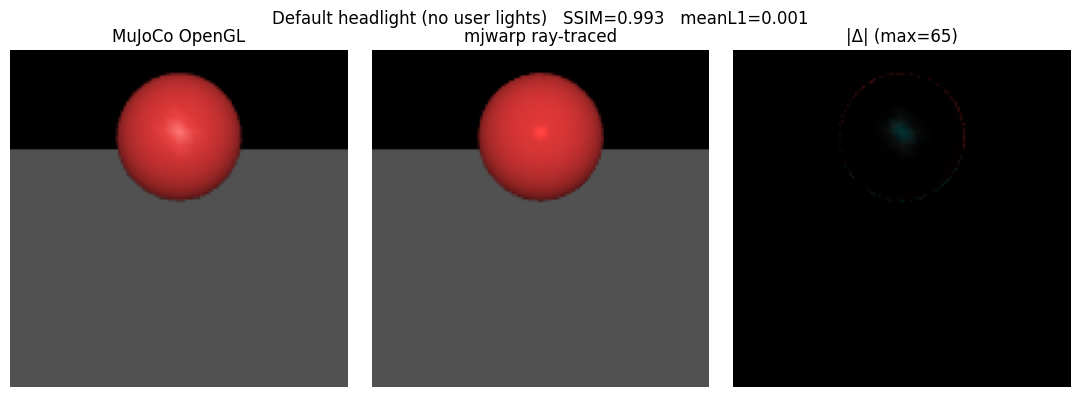

(0.992790937423706, 0.0012925091432407498)

In [3]:
HEADLIGHT_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.3 0.3 0.3" diffuse="0.8 0.8 0.8" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.5" xyaxes="1 0 0 0 0.3 1" resolution="128 128"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.6 0.6 0.6 1"/>
    <geom name="ball" type="sphere" pos="0 0 0.3" size="0.3" rgba="0.8 0.2 0.2 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(HEADLIGHT_XML)
print(f"nlight = {mjm.nlight}, headlight.active = {mjm.vis.headlight.active}")
compare_renders("Default headlight (no user lights)", mjm)

## 2. Spotlight cutoff & exponent sweep

Sweeping `cutoff` (cone half-angle, degrees) keeps the spotlight aimed
straight down and varies how wide the bright disk on the floor is. Sweeping
`exponent` controls how sharp the falloff is *within* the cone (higher =
tighter hotspot, lower = flat plateau).

Before Phase 1, mjwarp hardcoded `cutoff=18°/32°` and a linear ramp — every
spot light looked identical. Now both parameters drive the render.

Module render__locals___render_megakernel_f0adb2c9 14bb625 load on device 'cpu' took 504.87 ms  (compiled)


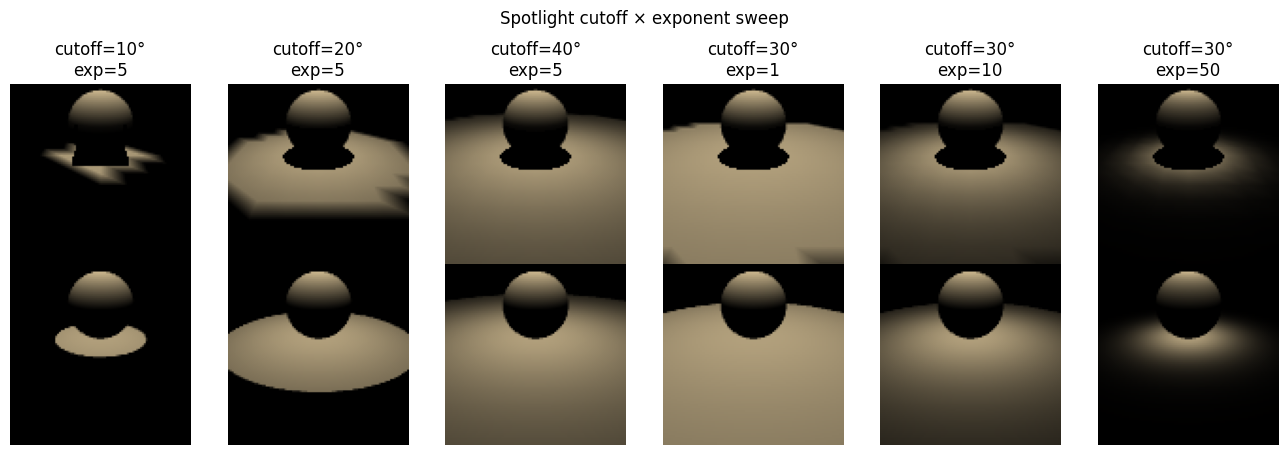

In [4]:
SPOT_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.8" xyaxes="1 0 0 0 0.5 1" resolution="96 96"/>
    <light pos="0 0 2.5" dir="0 0 -1" cutoff="{cutoff}" exponent="{exponent}"
           diffuse="1 0.9 0.7" specular="0 0 0" ambient="0 0 0" attenuation="1 0 0"/>
    <geom name="floor" type="plane" size="2 2 0.1" rgba="0.7 0.7 0.7 1"/>
    <geom name="ball" type="sphere" pos="0 0 0.3" size="0.3" rgba="0.8 0.8 0.8 1"/>
  </worldbody>
</mujoco>
"""

sweeps = [(10, 5), (20, 5), (40, 5), (30, 1), (30, 10), (30, 50)]
fig, axes = plt.subplots(2, len(sweeps), figsize=(2.2 * len(sweeps), 4.6))
for col, (cutoff, exponent) in enumerate(sweeps):
  mjm = mujoco.MjModel.from_xml_string(SPOT_XML.format(cutoff=cutoff, exponent=exponent))
  mj = mujoco_render(mjm, 96, 96)
  warp = mjwarp_render(mjm, 96, 96)
  axes[0, col].imshow(mj)
  axes[0, col].set_title(f"cutoff={cutoff}°\nexp={exponent}")
  axes[0, col].axis("off")
  axes[1, col].imshow(warp)
  axes[1, col].axis("off")
axes[0, 0].set_ylabel("MuJoCo", fontsize=10)
axes[1, 0].set_ylabel("mjwarp", fontsize=10)
fig.suptitle("Spotlight cutoff × exponent sweep")
plt.tight_layout()
plt.show()

## 3. Distance attenuation sweep

OpenGL's three-coefficient attenuation: `atten = 1 / (a0 + a1·d + a2·d²)`.
mjwarp used to hardcode `(1, 0, 0.02)` regardless of the model; now it reads
`light_attenuation` and matches OpenGL's behavior across coefficient choices.

Module render__locals___render_megakernel_cde20049 3aef673 load on device 'cpu' took 502.54 ms  (compiled)


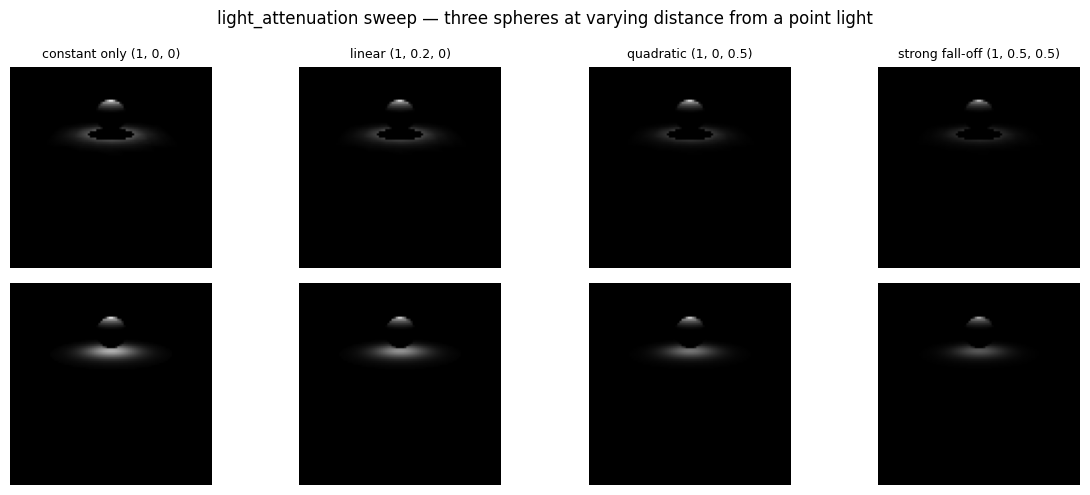

In [5]:
ATTEN_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -4 1" xyaxes="1 0 0 0 0.4 1" resolution="96 96"/>
    <light pos="0 0 1" diffuse="1 1 1" specular="0 0 0" ambient="0 0 0" attenuation="{a0} {a1} {a2}"/>
    <geom name="floor" type="plane" size="3 3 0.1" rgba="0.7 0.7 0.7 1"/>
    <geom name="b1" type="sphere" pos="-1.5 0 0.3" size="0.25" rgba="1 1 1 1"/>
    <geom name="b2" type="sphere" pos=" 0   0 0.3" size="0.25" rgba="1 1 1 1"/>
    <geom name="b3" type="sphere" pos=" 1.5 0 0.3" size="0.25" rgba="1 1 1 1"/>
  </worldbody>
</mujoco>
"""

attens = [
  ("constant only (1, 0, 0)", 1.0, 0.0, 0.0),
  ("linear (1, 0.2, 0)", 1.0, 0.2, 0.0),
  ("quadratic (1, 0, 0.5)", 1.0, 0.0, 0.5),
  ("strong fall-off (1, 0.5, 0.5)", 1.0, 0.5, 0.5),
]
fig, axes = plt.subplots(2, len(attens), figsize=(3 * len(attens), 5))
for col, (label, a0, a1, a2) in enumerate(attens):
  mjm = mujoco.MjModel.from_xml_string(ATTEN_XML.format(a0=a0, a1=a1, a2=a2))
  axes[0, col].imshow(mujoco_render(mjm, 96, 96))
  axes[0, col].set_title(label, fontsize=9)
  axes[0, col].axis("off")
  axes[1, col].imshow(mjwarp_render(mjm, 96, 96))
  axes[1, col].axis("off")
fig.suptitle("light_attenuation sweep — three spheres at varying distance from a point light")
plt.tight_layout()
plt.show()

## 4. Per-light color

Two directional lights of distinct color (red and blue) should yield a
purple cross-illumination region in the middle and pure red / blue lobes on
the sides. Before Phase 1, all lights contributed identical white in
mjwarp.

Module render__locals___render_megakernel_ebfe7364 eb38345 load on device 'cpu' took 526.70 ms  (compiled)


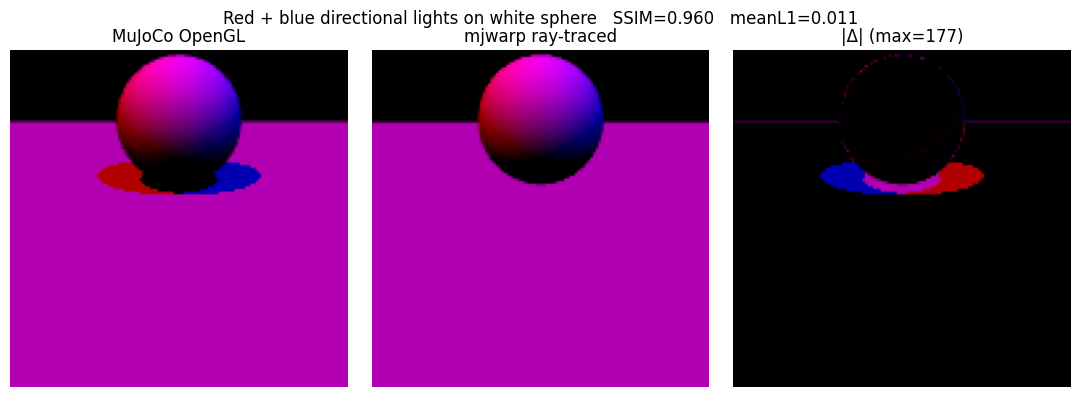

(0.9597508907318115, 0.010744420811533928)

In [6]:
TWO_LIGHTS_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.6" xyaxes="1 0 0 0 0.4 1" resolution="128 128"/>
    <light pos="-1 -1 2" dir="0.4 0.4 -1" directional="true" diffuse="1 0 0"
           specular="0 0 0" ambient="0 0 0"/>
    <light pos=" 1 -1 2" dir="-0.4 0.4 -1" directional="true" diffuse="0 0 1"
           specular="0 0 0" ambient="0 0 0"/>
    <geom type="plane" size="2 2 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="sphere" pos="0 0 0.3" size="0.3" rgba="1 1 1 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(TWO_LIGHTS_XML)
compare_renders("Red + blue directional lights on white sphere", mjm)

## 5. Specular highlights (Phong)

Sweeping `shininess` (stored in [0, 1], mapped to OpenGL exponent in
[0, 128]) controls the tightness of the highlight: low shininess = broad
soft highlight, high shininess = small intense hotspot.

Sweeping `specular` controls the highlight intensity.

Module render__locals___render_megakernel_67424983 2031ac8 load on device 'cpu' took 444.62 ms  (compiled)


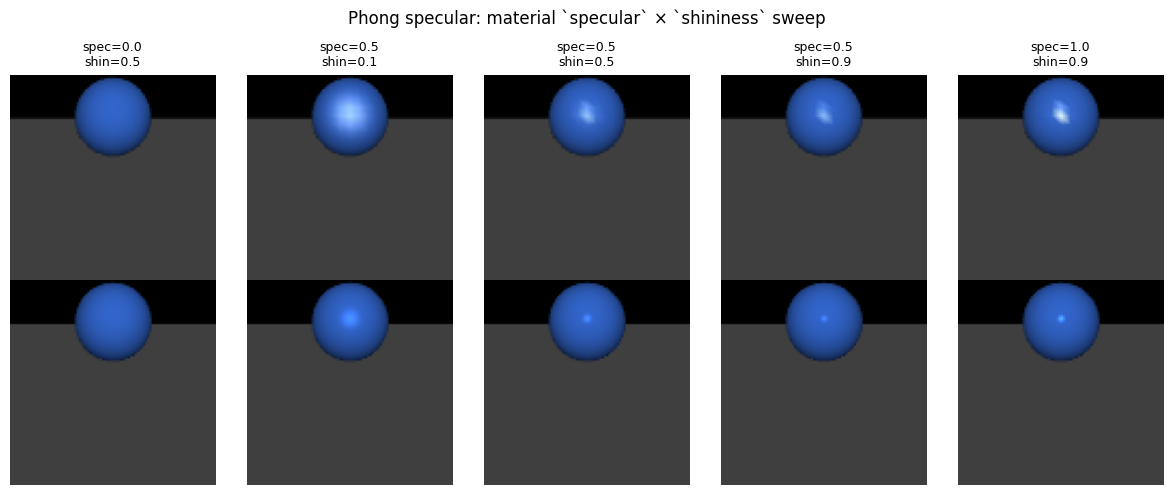

In [7]:
SPECULAR_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.8 0.8 0.8" specular="0.9 0.9 0.9"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="m" specular="{spec}" shininess="{shin}" rgba="0.2 0.4 0.8 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.6" xyaxes="1 0 0 0 0.4 1" resolution="96 96"/>
    <geom type="plane" size="2 2 0.1" rgba="0.5 0.5 0.5 1"/>
    <geom type="sphere" pos="0 0 0.3" size="0.3" material="m"/>
  </worldbody>
</mujoco>
"""

specs = [(0.0, 0.5), (0.5, 0.1), (0.5, 0.5), (0.5, 0.9), (1.0, 0.9)]
fig, axes = plt.subplots(2, len(specs), figsize=(2.4 * len(specs), 5))
for col, (spec, shin) in enumerate(specs):
  mjm = mujoco.MjModel.from_xml_string(SPECULAR_XML.format(spec=spec, shin=shin))
  axes[0, col].imshow(mujoco_render(mjm, 96, 96))
  axes[0, col].set_title(f"spec={spec}\nshin={shin}", fontsize=9)
  axes[0, col].axis("off")
  axes[1, col].imshow(mjwarp_render(mjm, 96, 96))
  axes[1, col].axis("off")
fig.suptitle("Phong specular: material `specular` × `shininess` sweep")
plt.tight_layout()
plt.show()

## 6. Material emission

`mat_emission` is a scalar self-illumination factor. With no lights in the
scene and emission > 0, the geom should still be visible (and tinted by its
diffuse color).

Module render__locals___render_megakernel_54a78b80 81aa0cf load on device 'cpu' took 421.81 ms  (compiled)


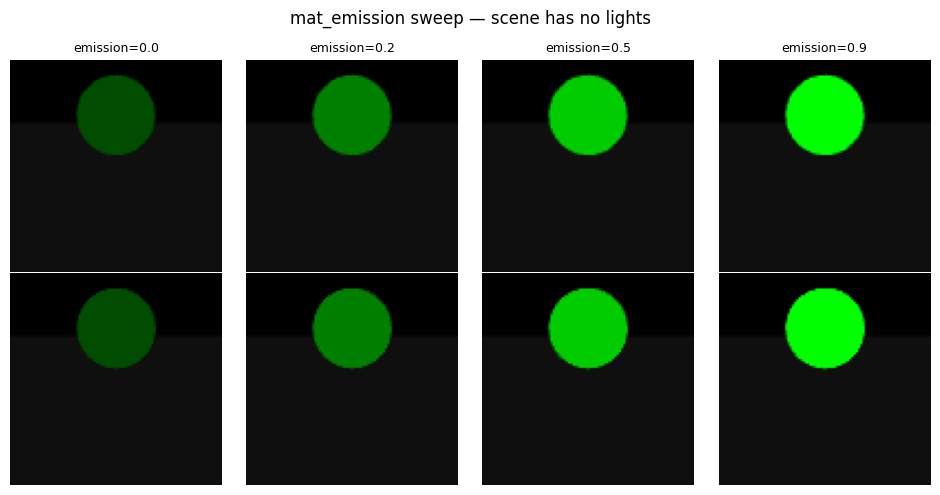

In [8]:
EMISSION_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="glow" emission="{emis}" rgba="0 1 0 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.5" xyaxes="1 0 0 0 0.3 1" resolution="96 96"/>
    <geom type="plane" size="2 2 0.1" rgba="0.2 0.2 0.2 1"/>
    <geom type="sphere" pos="0 0 0.3" size="0.3" material="glow"/>
  </worldbody>
</mujoco>
"""

emissions = [0.0, 0.2, 0.5, 0.9]
fig, axes = plt.subplots(2, len(emissions), figsize=(2.4 * len(emissions), 5))
for col, emis in enumerate(emissions):
  mjm = mujoco.MjModel.from_xml_string(EMISSION_XML.format(emis=emis))
  axes[0, col].imshow(mujoco_render(mjm, 96, 96))
  axes[0, col].set_title(f"emission={emis}", fontsize=9)
  axes[0, col].axis("off")
  axes[1, col].imshow(mjwarp_render(mjm, 96, 96))
  axes[1, col].axis("off")
fig.suptitle("mat_emission sweep — scene has no lights")
plt.tight_layout()
plt.show()

## 7. Shadows

mjwarp's shadow rays produce geometrically exact, aliasing-free shadow
boundaries — strictly better than OpenGL shadow maps but not pixel-identical.
Phase 1 also changed mjwarp's shadow visibility from `0.3` (partial) to `0.0`
(binary), matching OpenGL.

Module render__locals___render_megakernel_a855ee74 38663e6 load on device 'cpu' took 503.99 ms  (compiled)


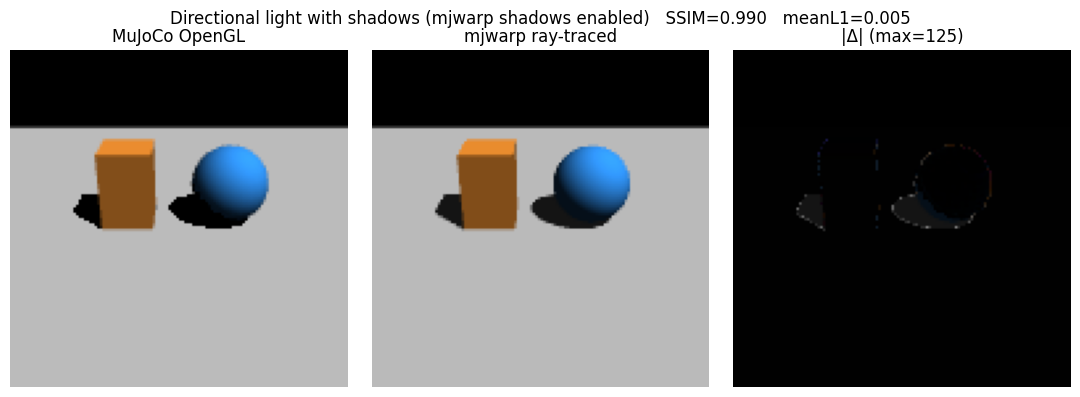

(0.9900133609771729, 0.005156632978469133)

In [9]:
SHADOW_XML = """
<mujoco>
  <visual>
    <headlight active="0" ambient="0 0 0" diffuse="0 0 0" specular="0 0 0"/>
    <map znear="0.01"/>
    <quality shadowsize="2048"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -3 1.5" xyaxes="1 0 0 0 0.5 1" resolution="128 128"/>
    <light pos="2 -2 4" dir="-0.5 0.5 -1" directional="true" castshadow="true"
           diffuse="1 1 1" specular="0 0 0" ambient="0.1 0.1 0.1"/>
    <geom type="plane" size="3 3 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="box" pos="-0.4 0 0.3" size="0.2 0.2 0.3" rgba="1 0.6 0.2 1"/>
    <geom type="sphere" pos="0.4 0 0.3" size="0.3" rgba="0.2 0.6 1 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(SHADOW_XML)
compare_renders("Directional light with shadows (mjwarp shadows enabled)", mjm, use_shadows=True)

## 8. Supersample anti-aliasing (MSAA)

A single ray per pixel produces visible stair-stepping along geom
silhouettes. `create_render_context(samples_per_pixel=N)` fires N jittered
rays per pixel using a Halton(2, 3) low-discrepancy pattern and averages the
results, producing smooth silhouettes at proportionally higher shading cost.

The sweep below uses a low resolution (32×32) so the aliasing at N=1 is
obvious, then shows N=4 and N=16. The MuJoCo OpenGL reference is on the left
for comparison.

Module render__locals___render_megakernel_b784d3df 671f481 load on device 'cpu' took 444.57 ms  (compiled)


Module render__locals___render_megakernel_74561415 dc11bcf load on device 'cpu' took 443.04 ms  (compiled)


Module render__locals___render_megakernel_dce1cc97 2b359c9 load on device 'cpu' took 444.19 ms  (compiled)


Module render__locals___render_megakernel_4c16ef45 66c5683 load on device 'cpu' took 442.55 ms  (compiled)


Module render__locals___render_megakernel_376d5031 9213a7b load on device 'cpu' took 441.95 ms  (compiled)


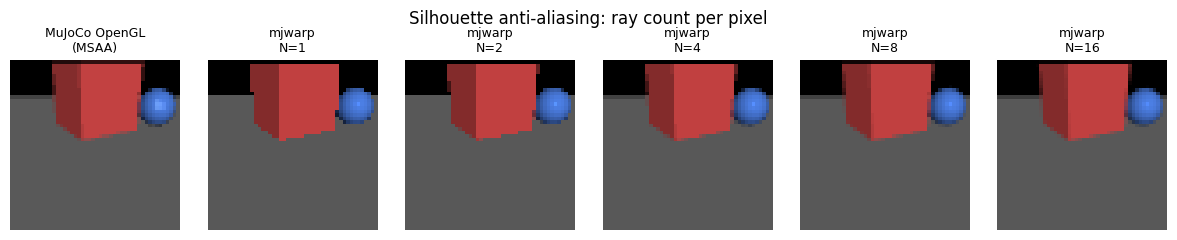

In [10]:
MSAA_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.8 0.8 0.8" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <worldbody>
    <camera name="cam" pos="0 -2 0.6" xyaxes="1 0 0 0 0.4 1" resolution="48 48"/>
    <geom type="plane" size="2 2 0.1" rgba="0.7 0.7 0.7 1"/>
    <geom type="box" pos="0 0 0.3" size="0.3 0.3 0.3" euler="0 0 30" rgba="0.9 0.3 0.3 1"/>
    <geom type="sphere" pos="0.6 0 0.2" size="0.18" rgba="0.3 0.5 0.9 1"/>
  </worldbody>
</mujoco>
"""

mjm = mujoco.MjModel.from_xml_string(MSAA_XML)
mj = mujoco_render(mjm, 48, 48)

samples = [1, 2, 4, 8, 16]
fig, axes = plt.subplots(1, len(samples) + 1, figsize=(2.0 * (len(samples) + 1), 2.4))
axes[0].imshow(mj, interpolation="nearest")
axes[0].set_title("MuJoCo OpenGL\n(MSAA)", fontsize=9)
axes[0].axis("off")
for col, n in enumerate(samples, start=1):
  img = mjwarp_render(mjm, 48, 48, samples_per_pixel=n)
  axes[col].imshow(img, interpolation="nearest")
  axes[col].set_title(f"mjwarp\nN={n}", fontsize=9)
  axes[col].axis("off")
fig.suptitle("Silhouette anti-aliasing: ray count per pixel")
plt.tight_layout()
plt.show()

### MSAA cost

MSAA scales linearly with `samples_per_pixel` since each sample re-casts a
primary ray and re-evaluates the full shading chain. Background pixels are
cheaper than hit pixels.

In [11]:
def bench_msaa(mjm, w, h, n_samples):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd)
  rc = mjw.create_render_context(mjm, cam_res=(w, h), render_rgb=True, samples_per_pixel=n_samples)
  def step():
    mjw.render(m, d, rc)
    wp.synchronize()
  # warm up to compile the kernel for this N
  for _ in range(2):
    step()
  ts = []
  for _ in range(5):
    t0 = time.perf_counter()
    step()
    ts.append(time.perf_counter() - t0)
  return float(np.median(ts))


mjm_bench_msaa = mujoco.MjModel.from_xml_string(MSAA_XML)
ns = [1, 2, 4, 8, 16]
times = [bench_msaa(mjm_bench_msaa, 128, 128, n) for n in ns]
print(f"{'N':>3s}  {'time (ms)':>10s}  {'cost/sample (ms)':>17s}")
for n, t in zip(ns, times):
  print(f"{n:>3d}  {t * 1000:>10.2f}  {t * 1000 / n:>17.3f}")

  N   time (ms)   cost/sample (ms)
  1       10.93             10.930
  2       11.56              5.781
  4       12.73              3.182
  8       15.22              1.903
 16       19.99              1.249


## 8. SSIM summary across all canonical fixtures

Aggregate parity numbers for the same fixtures used in
`render_parity_test.py`. On a healthy build all SSIM scores should sit
comfortably above the test thresholds.

In [12]:
from mujoco_warp._src.render_parity_test import (
  _FIXTURE_EMISSION,
  _FIXTURE_HEADLIGHT_ONLY,
  _FIXTURE_SPECULAR,
  _FIXTURE_SPOTLIGHT,
  _FIXTURE_TWO_LIGHTS,
)

fixtures = [
  ("headlight_only", _FIXTURE_HEADLIGHT_ONLY),
  ("spotlight", _FIXTURE_SPOTLIGHT),
  ("specular", _FIXTURE_SPECULAR),
  ("two_lights", _FIXTURE_TWO_LIGHTS),
  ("emission", _FIXTURE_EMISSION),
]

rows = []
for name, xml in fixtures:
  mjm = mujoco.MjModel.from_xml_string(xml)
  warp_rgb = mjwarp_render(mjm, 64, 64)
  mj_rgb = mujoco_render(mjm, 64, 64)
  rows.append((name, ssim_luma(warp_rgb, mj_rgb), mean_l1(warp_rgb, mj_rgb)))

print(f"{'fixture':<18s} {'SSIM':>7s} {'meanL1':>9s}")
print("-" * 38)
for name, ssim, l1 in rows:
  print(f"{name:<18s} {ssim:>7.4f} {l1:>9.4f}")

fixture               SSIM    meanL1
--------------------------------------
headlight_only      0.9880    0.0017
spotlight           0.8513    0.0326
specular            0.9740    0.0029
two_lights          0.9471    0.0112
emission            0.9968    0.0010


## 9. Performance benchmarks

Comparing the two renderers on the same scene at increasing image
resolutions, and (for mjwarp only, since `mujoco.Renderer` is single-scene)
across increasing world counts.

Each measurement is the median of `n_repeats` runs after a warmup, so the
first kernel compile is excluded.

> On CPU-only Warp builds the multi-world numbers are not representative of
> production GPU throughput; they're shown to verify the kernel scales
> linearly with world count rather than catastrophically.

In [13]:
BENCH_XML = """
<mujoco>
  <visual>
    <headlight active="1" ambient="0.2 0.2 0.2" diffuse="0.7 0.7 0.7" specular="0.5 0.5 0.5"/>
    <map znear="0.01"/>
  </visual>
  <asset>
    <material name="shiny" specular="0.7" shininess="0.6" rgba="0.4 0.5 0.8 1"/>
  </asset>
  <worldbody>
    <camera name="cam" pos="0 -2 0.8" xyaxes="1 0 0 0 0.4 1" resolution="64 64"/>
    <light pos="1 -1 2" dir="-0.4 0.5 -1" diffuse="0.8 0.8 0.7" specular="0.5 0.5 0.5"
           ambient="0.05 0.05 0.05" attenuation="1 0 0" castshadow="false"/>
    <geom type="plane" size="3 3 0.1" rgba="0.8 0.8 0.8 1"/>
    <geom type="box"     pos="-0.6 0 0.25" size="0.2 0.2 0.25" material="shiny"/>
    <geom type="sphere"  pos=" 0   0 0.30" size="0.30" material="shiny"/>
    <geom type="capsule" pos=" 0.6 0 0.30" size="0.15 0.15" material="shiny"/>
  </worldbody>
</mujoco>
"""


def time_call(fn, n_warmup: int = 2, n_repeats: int = 5) -> float:
  for _ in range(n_warmup):
    fn()
  ts = []
  for _ in range(n_repeats):
    t0 = time.perf_counter()
    fn()
    ts.append(time.perf_counter() - t0)
  return float(np.median(ts))


def bench_mujoco(mjm, w, h, n_warmup=2, n_repeats=5):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  with mujoco.Renderer(mjm, height=h, width=w) as r:
    def step():
      r.update_scene(mjd, camera=0)
      r.render()
    return time_call(step, n_warmup, n_repeats)


def bench_mjwarp(mjm, w, h, nworld=1, n_warmup=2, n_repeats=5):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd, nworld=nworld)
  rc = mjw.create_render_context(mjm, nworld=nworld, cam_res=(w, h), render_rgb=True, use_shadows=False)
  def step():
    mjw.render(m, d, rc)
    wp.synchronize()
  return time_call(step, n_warmup, n_repeats)

### Resolution sweep — single-world

`mujoco.Renderer` only renders one scene at a time. mjwarp's per-world cost
is dominated by `total_rays = W·H` per camera, so we expect roughly linear
growth with pixel count.

Module render__locals___render_megakernel_a37a2206 32e3ef1 load on device 'cpu' took 526.59 ms  (compiled)
  32x32    mujoco=   0.67 ms   mjwarp=  10.04 ms
  64x64    mujoco=   0.39 ms   mjwarp=  10.35 ms


  96x96    mujoco=   0.37 ms   mjwarp=  11.11 ms
 128x128   mujoco=   0.36 ms   mjwarp=  12.17 ms


 192x192   mujoco=   0.41 ms   mjwarp=  15.83 ms
 256x256   mujoco=   0.44 ms   mjwarp=  19.63 ms


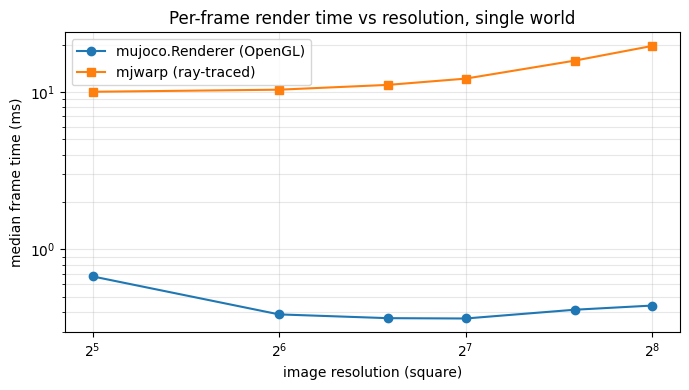

In [14]:
mjm_bench = mujoco.MjModel.from_xml_string(BENCH_XML)
resolutions = [32, 64, 96, 128, 192, 256]

mj_times = []
warp_times = []
for r in resolutions:
  mj_t = bench_mujoco(mjm_bench, r, r)
  wp_t = bench_mjwarp(mjm_bench, r, r, nworld=1)
  mj_times.append(mj_t)
  warp_times.append(wp_t)
  print(f"{r:>4d}x{r:<4d}  mujoco={mj_t * 1000:7.2f} ms   mjwarp={wp_t * 1000:7.2f} ms")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(resolutions, np.array(mj_times) * 1000, "o-", label="mujoco.Renderer (OpenGL)")
ax.plot(resolutions, np.array(warp_times) * 1000, "s-", label="mjwarp (ray-traced)")
ax.set_xlabel("image resolution (square)")
ax.set_ylabel("median frame time (ms)")
ax.set_title("Per-frame render time vs resolution, single world")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### World-count scaling — mjwarp only

`mujoco.Renderer` can't batch worlds, so this scaling chart only applies to
mjwarp. We expect throughput in frames/sec to grow with world count on a
healthy GPU (the kernel parallelizes over both worlds and rays), bottoming
out only when the device saturates.

Adjust `world_counts` based on your hardware. On CPU we cap at small
values to keep the notebook responsive.

nworld=    1  total=   10.41 ms   per-world= 10.407 ms   FPS×worlds=       96
nworld=    4  total=   12.12 ms   per-world=  3.030 ms   FPS×worlds=      330


nworld=   16  total=   19.75 ms   per-world=  1.234 ms   FPS×worlds=      810


nworld=   64  total=   49.93 ms   per-world=  0.780 ms   FPS×worlds=    1,282


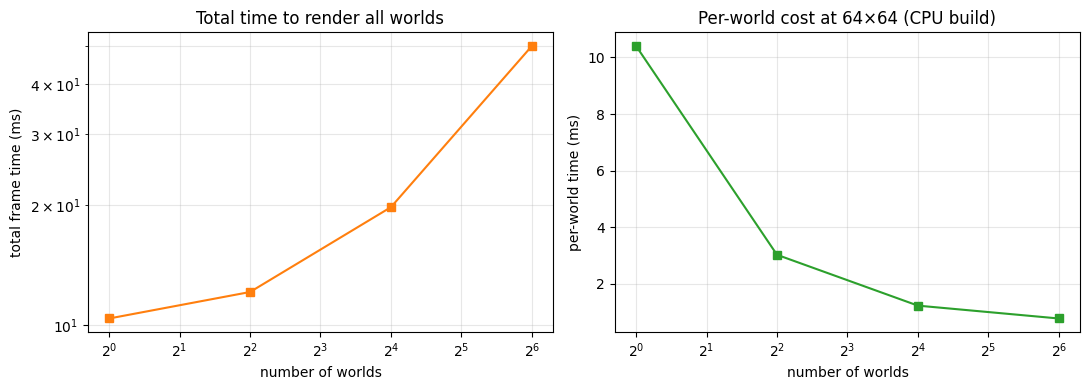

In [15]:
has_cuda = wp.get_cuda_device_count() > 0
if has_cuda:
  world_counts = [1, 4, 16, 64, 256, 1024]
else:
  world_counts = [1, 4, 16, 64]

cam_w = cam_h = 64
frame_times = []
for n in world_counts:
  t = bench_mjwarp(mjm_bench, cam_w, cam_h, nworld=n)
  frame_times.append(t)
  fps_per_world = n / t
  print(f"nworld={n:>5d}  total={t * 1000:8.2f} ms   per-world={t * 1000 / n:7.3f} ms   FPS×worlds={fps_per_world:>9,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(world_counts, np.array(frame_times) * 1000, "s-", color="C1")
axes[0].set_xlabel("number of worlds")
axes[0].set_ylabel("total frame time (ms)")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log")
axes[0].set_title("Total time to render all worlds")
axes[0].grid(True, which="both", alpha=0.3)

per_world = np.array(frame_times) * 1000 / np.array(world_counts)
axes[1].plot(world_counts, per_world, "s-", color="C2")
axes[1].set_xlabel("number of worlds")
axes[1].set_ylabel("per-world time (ms)")
axes[1].set_xscale("log", base=2)
axes[1].set_title(f"Per-world cost at {cam_w}×{cam_h} ({'CUDA' if has_cuda else 'CPU'} build)")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

### Shadow cost

Enabling shadows roughly doubles per-pixel work because every lit pixel
casts an additional shadow ray per active light. This cell quantifies that
overhead on the benchmark scene.

In [16]:
SHADOW_BENCH_XML = BENCH_XML.replace('castshadow="false"', 'castshadow="true"')
mjm_shadow = mujoco.MjModel.from_xml_string(SHADOW_BENCH_XML)


def bench_mjwarp_shadows(mjm, w, h, use_shadows: bool, nworld=1):
  mjd = mujoco.MjData(mjm)
  mujoco.mj_forward(mjm, mjd)
  m = mjw.put_model(mjm)
  d = mjw.put_data(mjm, mjd, nworld=nworld)
  rc = mjw.create_render_context(mjm, nworld=nworld, cam_res=(w, h), render_rgb=True, use_shadows=use_shadows)
  def step():
    mjw.render(m, d, rc)
    wp.synchronize()
  return time_call(step)


for r in [64, 128, 256]:
  t_off = bench_mjwarp_shadows(mjm_shadow, r, r, use_shadows=False)
  t_on = bench_mjwarp_shadows(mjm_shadow, r, r, use_shadows=True)
  print(f"{r:>4d}x{r:<4d}  shadows off={t_off * 1000:6.2f} ms   on={t_on * 1000:6.2f} ms   ratio={t_on / t_off:.2f}x")

  64x64    shadows off= 10.31 ms   on= 10.47 ms   ratio=1.02x


 128x128   shadows off= 12.46 ms   on= 12.72 ms   ratio=1.02x


 256x256   shadows off= 19.59 ms   on= 21.66 ms   ratio=1.11x


## Summary

If all the side-by-side comparisons above show mjwarp tracking MuJoCo OpenGL
qualitatively (and the SSIM table at section 8 is all green), the Phase 1
parity work is functioning end-to-end on this build.

Remaining differences in the diff panels (e.g. the spot cone boundary,
ball silhouette, specular hotspot shape) are structural consequences of
per-pixel ray tracing vs per-vertex Gouraud shading and cannot be fully
closed without changing the rasterized reference itself. Phase 2/3 will
*widen* the gap in mjwarp's favor (soft shadows, Fresnel, GGX) — Phase 1's
goal was just to make mjwarp respond to the same knobs that OpenGL does.